# Clickstream Data for Online Shopping

- Customer Behavior Analysis Using Clickstream Data for Online Shopping
- Problem Statement
- Online shopping platforms generate large volumes of clickstream data from users browsing their websites. Understanding these user interactions can help businesses predict customer behavior, improve user experience, and increase sales conversions.
The goal of this project is to analyze customer clickstream data to identify browsing patterns and predict user actions such as purchases or product interest.

- Clickstream data records every action a user performs on a website.
- It tracks the sequence of clicks and pages visited by users during an online session.
- Examples of user actions recorded:
- Page views
- Product clicks
- Category browsing
- Add to cart
- Checkout behavior
- Time spent on pages
- This data helps businesses understand customer navigation patterns.

# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier

import pickle

import warnings 
warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
df=pd.read_csv("e-shop clothing 2008.csv",sep=';')

In [3]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


In [4]:
df.columns

Index(['year', 'month', 'day', 'order', 'country', 'session ID',
       'page 1 (main category)', 'page 2 (clothing model)', 'colour',
       'location', 'model photography', 'price', 'price 2', 'page'],
      dtype='object')

In [5]:
df = df.drop(['year','session ID'], axis=1)

# Data Cleaning

In [6]:
df.shape

(165474, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   month                    165474 non-null  int64 
 1   day                      165474 non-null  int64 
 2   order                    165474 non-null  int64 
 3   country                  165474 non-null  int64 
 4   page 1 (main category)   165474 non-null  int64 
 5   page 2 (clothing model)  165474 non-null  object
 6   colour                   165474 non-null  int64 
 7   location                 165474 non-null  int64 
 8   model photography        165474 non-null  int64 
 9   price                    165474 non-null  int64 
 10  price 2                  165474 non-null  int64 
 11  page                     165474 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 15.1+ MB


In [8]:
df.duplicated().sum()

np.int64(31934)

In [9]:
df.isnull().sum()

month                      0
day                        0
order                      0
country                    0
page 1 (main category)     0
page 2 (clothing model)    0
colour                     0
location                   0
model photography          0
price                      0
price 2                    0
page                       0
dtype: int64

In [16]:
num_cols = df.select_dtypes(include = ['int64','float64']).columns
num_cols

Index(['month', 'day', 'order', 'country', 'page_1_main_category', 'colour',
       'location', 'model_photography', 'price', 'price_2', 'page'],
      dtype='object')

In [17]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")

In [18]:
df.columns

Index(['month', 'day', 'order', 'country', 'page_1_main_category',
       'page_2_clothing_model', 'colour', 'location', 'model_photography',
       'price', 'price_2', 'page'],
      dtype='object')

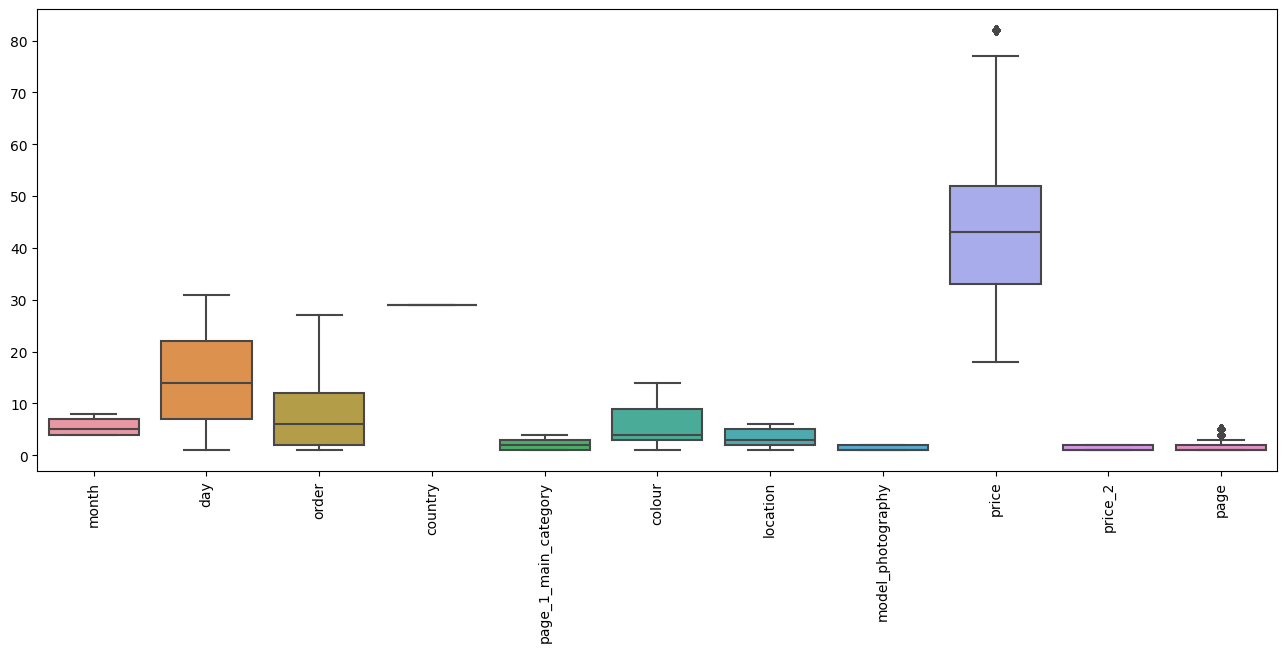

In [19]:
plt.figure(figsize=(16,6))
sns.boxplot(df)
plt.xticks(rotation=90);

In [22]:
for _ in range(4):
    for col in ['month', 'day', 'order', 'country','colour', 'location', 'model_photography',
       'price', 'price_2', 'page']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)

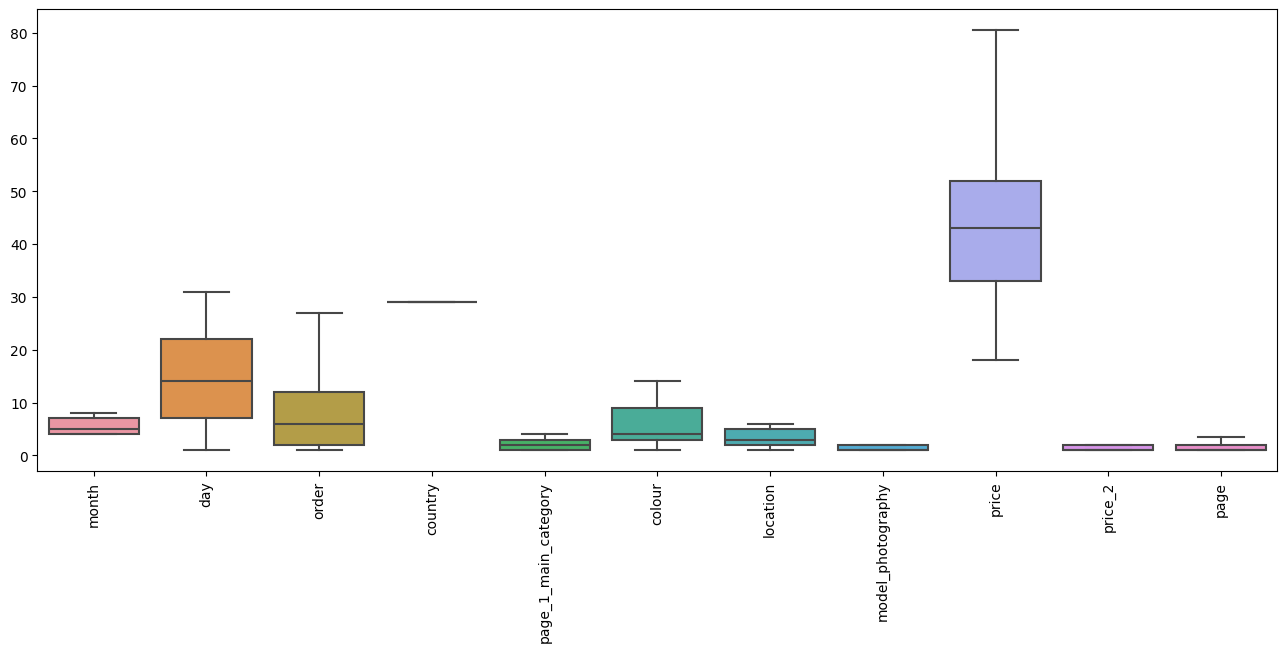

In [23]:
plt.figure(figsize=(16,6))
sns.boxplot(df)
plt.xticks(rotation=90);

# Feature Engineering

In [24]:
encoder = LabelEncoder()
df['page_2_clothing_model'] = encoder.fit_transform(df['page_2_clothing_model'])

# Define Target and Features

In [25]:
X = df.drop('page_1_main_category', axis=1)
y = df['page_1_main_category']

# Train Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Multiple ML Algorithms

In [28]:
models = {

"Logistic Regression": LogisticRegression(max_iter=200),

"Decision Tree": DecisionTreeClassifier(),

"KNN": KNeighborsClassifier(),

"SVM": SVC(),

"Naive Bayes": GaussianNB(),

"Random Forest": RandomForestClassifier(),

"Gradient Boosting": GradientBoostingClassifier(),

"AdaBoost": AdaBoostClassifier()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.9856775948028403
Decision Tree Accuracy: 1.0
KNN Accuracy: 0.9997884876869618
SVM Accuracy: 1.0
Naive Bayes Accuracy: 0.9475751624112404
Random Forest Accuracy: 1.0
Gradient Boosting Accuracy: 1.0
AdaBoost Accuracy: 0.4680767487535882


# Model Comparison

In [29]:
results_df = pd.DataFrame(list(results.items()), columns=['Model','Accuracy'])
print(results_df.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy
1        Decision Tree  1.000000
3                  SVM  1.000000
6    Gradient Boosting  1.000000
5        Random Forest  1.000000
2                  KNN  0.999788
0  Logistic Regression  0.985678
4          Naive Bayes  0.947575
7             AdaBoost  0.468077


# Ensemble Voting Model

In [30]:
voting_model = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier()),
        ('gb', GradientBoostingClassifier()),
        ('lr', LogisticRegression(max_iter=200))
    ],
    voting='hard'
)

voting_model.fit(X_train, y_train)

pred = voting_model.predict(X_test)

print("Voting Accuracy:", accuracy_score(y_test, pred))

Voting Accuracy: 1.0


# Best Model Selection

In [31]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
pickle.dump(best_model, open("clickstream_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [35]:
print(scaler.feature_names_in_)

['month' 'day' 'order' 'country' 'page_2_clothing_model' 'colour'
 'location' 'model_photography' 'price' 'price_2' 'page']


# Regression

# Import Libraries

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import VotingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

# Load Dataset

In [37]:
df = pd.read_csv("e-shop clothing 2008.csv", sep=";")

In [38]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


In [39]:
df = df.drop(['year','session ID'], axis=1)

In [40]:
df.shape

(165474, 12)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   month                    165474 non-null  int64 
 1   day                      165474 non-null  int64 
 2   order                    165474 non-null  int64 
 3   country                  165474 non-null  int64 
 4   page 1 (main category)   165474 non-null  int64 
 5   page 2 (clothing model)  165474 non-null  object
 6   colour                   165474 non-null  int64 
 7   location                 165474 non-null  int64 
 8   model photography        165474 non-null  int64 
 9   price                    165474 non-null  int64 
 10  price 2                  165474 non-null  int64 
 11  page                     165474 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 15.1+ MB


# Data Cleaning

In [42]:
print(df.isnull().sum())

month                      0
day                        0
order                      0
country                    0
page 1 (main category)     0
page 2 (clothing model)    0
colour                     0
location                   0
model photography          0
price                      0
price 2                    0
page                       0
dtype: int64


In [43]:
df.drop_duplicates(inplace=True)

In [44]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")

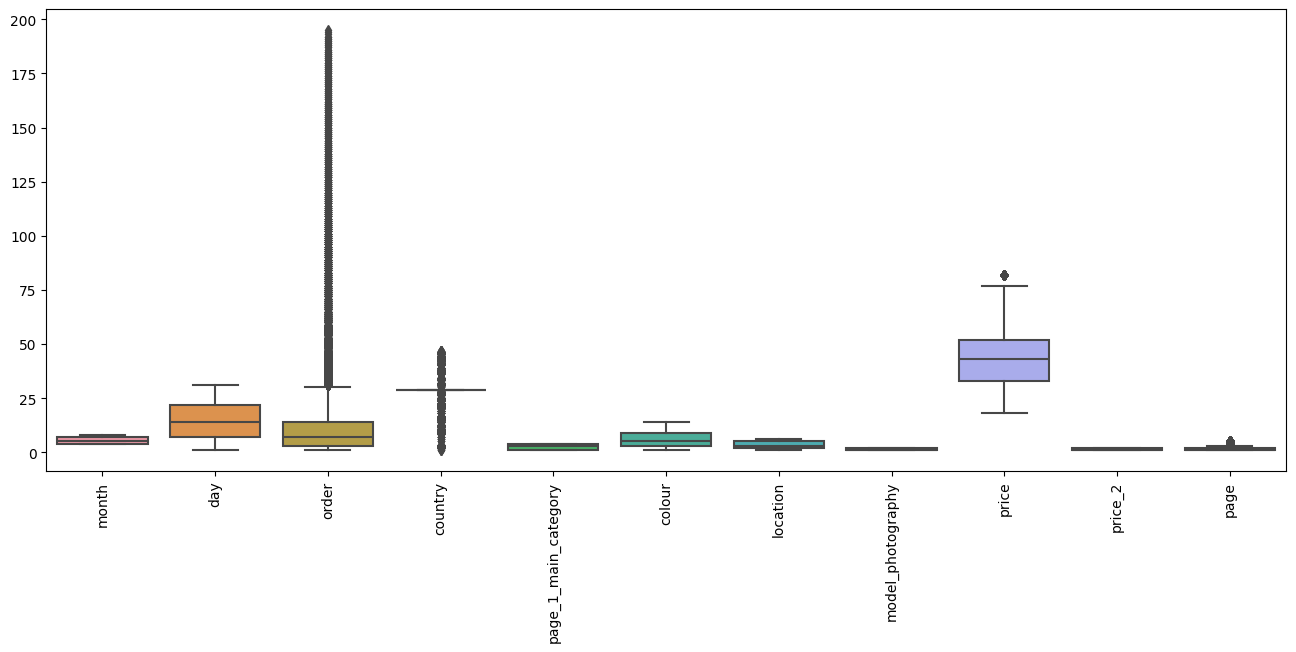

In [45]:
plt.figure(figsize=(16,6))
sns.boxplot(df)
plt.xticks(rotation=90);

In [46]:
for _ in range(4):
    for col in ['month', 'day', 'order', 'country','colour', 'location', 'model_photography',
       'price', 'price_2', 'page']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)

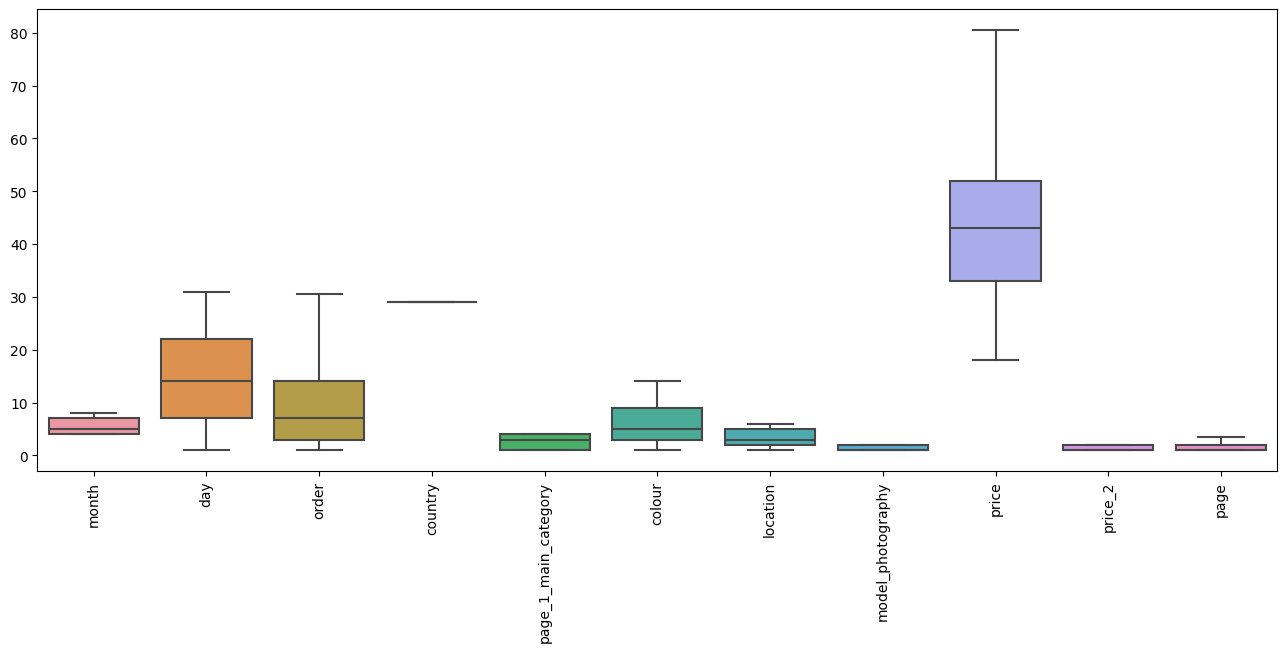

In [47]:
plt.figure(figsize=(16,6))
sns.boxplot(df)
plt.xticks(rotation=90);

# Encoding Categorical Variables

In [48]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

# Define Features and Target

In [49]:
X = df.drop("order", axis=1)
y = df["order"]

# Train Test Split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [51]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Multiple Regression Models

In [52]:
models = {

"Linear Regression": LinearRegression(),
"Decision Tree": DecisionTreeRegressor(),
"KNN": KNeighborsRegressor(),
"SVM": SVR(),
"Random Forest": RandomForestRegressor(),
"Gradient Boosting": GradientBoostingRegressor(),
"AdaBoost": AdaBoostRegressor()

}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results[name] = r2

    print("*"*40)
    print(name)
    print("*"*40)
    print("MAE:", mae)
    print("MSE:", mse)
    print("R2 Score:", r2)
    print("*"*40)

****************************************
Linear Regression
****************************************
MAE: 6.723792201145458
MSE: 71.85360881743253
R2 Score: 0.04804552321245115
****************************************
****************************************
Decision Tree
****************************************
MAE: 7.245387469617882
MSE: 88.69555983262342
R2 Score: -0.17508551962054053
****************************************
****************************************
KNN
****************************************
MAE: 7.127838100943537
MSE: 83.0618425190954
R2 Score: -0.10044706365662259
****************************************
****************************************
SVM
****************************************
MAE: 6.309044328325268
MSE: 79.28911405793139
R2 Score: -0.050463968758297284
****************************************
****************************************
Random Forest
****************************************
MAE: 7.0633738036217375
MSE: 82.63015821354409
R2 Score: -0.09472

# Best Model Selection

In [ ]:
best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

# Save Model (.pkl)

In [ ]:
#pickle.dump(best_model, open("clickstream_regression_model.pkl", "wb"))
#pickle.dump(scaler, open("scaler.pkl", "wb"))

# Unsupervised Machine Learning

# Import Libraries

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

# Load Dataset

In [34]:
df = pd.read_csv("e-shop clothing 2008.csv", sep=";")

In [35]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


In [36]:
df = df.drop(['session ID','page 1 (main category)','year'], axis=1)

In [37]:
df.shape

(165474, 11)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   month                    165474 non-null  int64 
 1   day                      165474 non-null  int64 
 2   order                    165474 non-null  int64 
 3   country                  165474 non-null  int64 
 4   page 2 (clothing model)  165474 non-null  object
 5   colour                   165474 non-null  int64 
 6   location                 165474 non-null  int64 
 7   model photography        165474 non-null  int64 
 8   price                    165474 non-null  int64 
 9   price 2                  165474 non-null  int64 
 10  page                     165474 non-null  int64 
dtypes: int64(10), object(1)
memory usage: 13.9+ MB


# Data Cleaning

In [39]:
df.isnull().sum()

month                      0
day                        0
order                      0
country                    0
page 2 (clothing model)    0
colour                     0
location                   0
model photography          0
price                      0
price 2                    0
page                       0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(31934)

In [41]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")

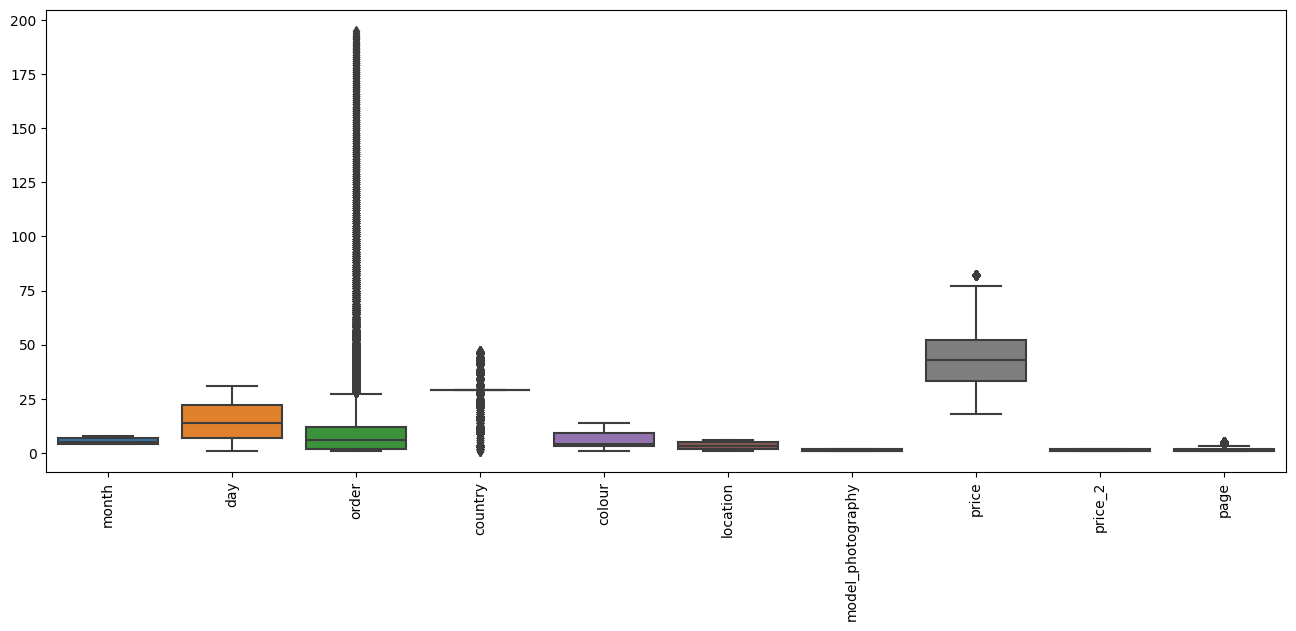

In [42]:
plt.figure(figsize=(16,6))
sns.boxplot(df)
plt.xticks(rotation=90);

In [43]:
for _ in range(4):
    for col in ['month', 'day', 'order', 'country','colour', 'location', 'model_photography',
       'price', 'price_2', 'page']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)

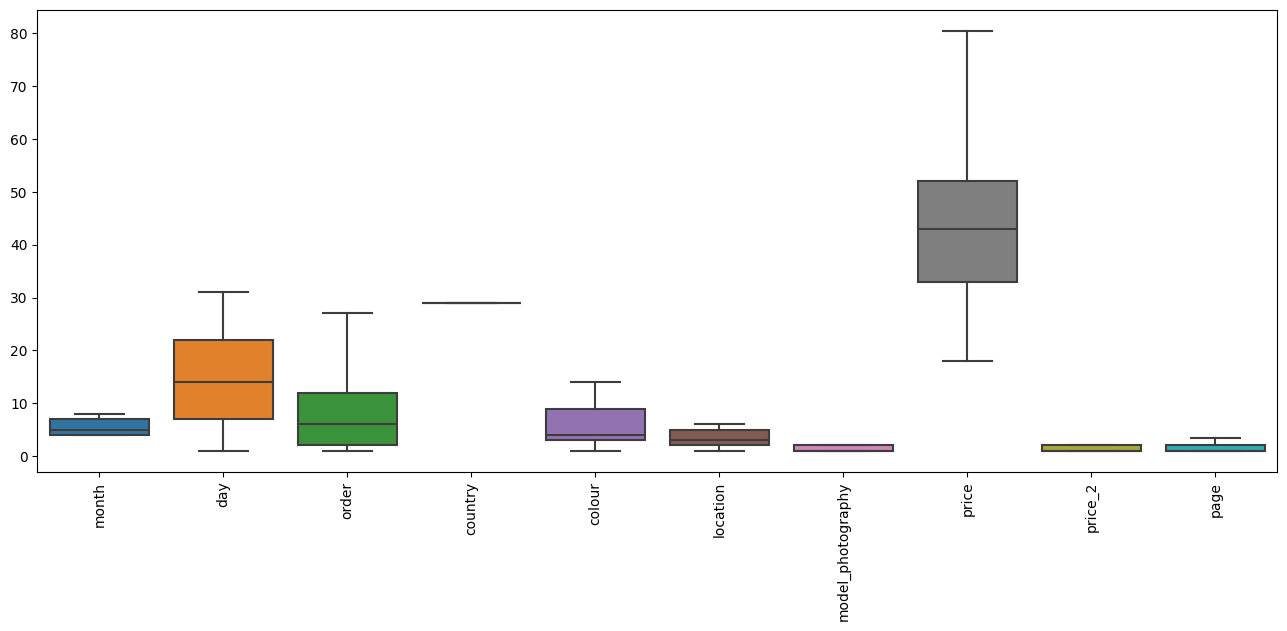

In [44]:
plt.figure(figsize=(16,6))
sns.boxplot(df)
plt.xticks(rotation=90);

# Encode Categorical Variables

In [45]:
df.select_dtypes(include='object').columns

Index(['page_2_clothing_model'], dtype='object')

In [46]:
encoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

# Feature Scaling

In [47]:
X = df[['month','day','order','country',
        'page_2_clothing_model','colour','location',
        'model_photography','price','price_2','page']]

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optimal Clusters (Elbow Method)

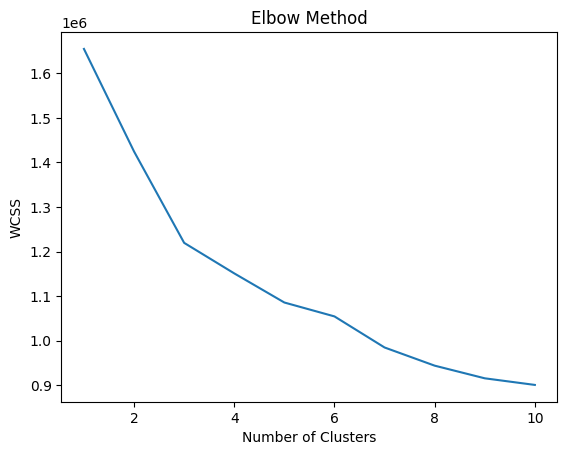

In [49]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# K-Means Clustering

In [61]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters1 = kmeans.fit_predict(X_scaled)
df['Cluster_KMeans'] = clusters1

# Cluster Evaluation

In [51]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.1626549829519036


# Hierarchical Clustering

In [30]:
df_sample = df.sample(5000, random_state=42)

# feature selection
X_sample = df_sample[['month','day','order','country',
                      'page_2_clothing_model','colour',
                      'location','model_photography',
                      'price','price_2','page']]

# scaling
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# hierarchical clustering
hc = AgglomerativeClustering(n_clusters=4)

clusters_hc = hc.fit_predict(X_sample_scaled)

# silhouette score
score = silhouette_score(X_sample_scaled, clusters_hc)

print("Silhouette Score:", score)

Silhouette Score: 0.1459835708258403


# DBSCAN Clustering

In [59]:
df_sample = df.sample(5000, random_state=42)

# feature selection
X_sample = df_sample[['month','day','order','country',
                      'page_2_clothing_model','colour',
                      'location','model_photography',
                      'price','price_2','page']]

# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)

clusters = dbscan.fit_predict(X_sample_scaled)

# assign clusters to sample dataframe
df_sample['Cluster_DBSCAN'] = clusters

print(df_sample['Cluster_DBSCAN'].value_counts())

# silhouette score
score = silhouette_score(X_sample_scaled, clusters)

print("Silhouette Score:", score)

Cluster_DBSCAN
-1     4317
 4       22
 30      20
 1       19
 44      19
       ... 
 68       5
 84       5
 63       5
 76       5
 71       5
Name: count, Length: 86, dtype: int64
Silhouette Score: -0.34480652691321817


# Cluster Visualization (PCA)

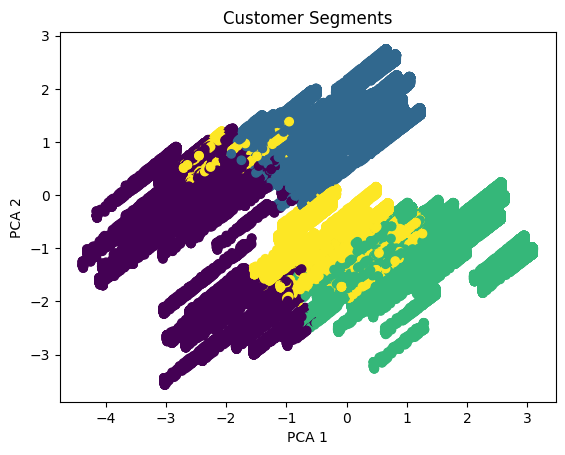

In [62]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters1)
plt.title("Customer Segments")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
# import pickle
# pickle.dump(kmeans, open("kmeans_model.pkl","wb"))
# pickle.dump(scaler, open("scaler.pkl","wb"))